# Calculate the profit difference between spot market and capture price contracts

Some traders are providing contracts that take into account a profit calculation basing on monthly system capture prices instead of spot market prices. This notebook calculates resulting difference of profits between these two methods.

In [81]:
import pandas as pd

### Read simulation results

In [82]:
results = pd.read_csv('results.csv', index_col=0)
results.index = pd.to_datetime(results.index)

### Annual capture price

In [83]:
annual_capture_price = 46.24

### Read monthly capture prices

In [84]:
monthly_system_capture_prices = pd.read_csv('2024_monatsmarktwerte.csv', sep=';').T
monthly_system_capture_prices = monthly_system_capture_prices.iloc[:, [7]] # Select only the column with solar capture prices
monthly_system_capture_prices = monthly_system_capture_prices.iloc[1:]
monthly_system_capture_prices.index = pd.date_range(start='2024-01-01', end='2024-12-31', freq='ME')
monthly_system_capture_prices.index = monthly_system_capture_prices.index - pd.offsets.MonthBegin(1)
monthly_system_capture_prices.columns = ['solar_capture_price']
monthly_system_capture_prices.head()

,solar_capture_price
2024-01-01,"7,535"
2024-02-01,"5,875"
2024-03-01,"4,965"
2024-04-01,"3,795"
2024-05-01,"3,161"


# Read DAA prices

In [85]:
import os

print(os.getcwd())

c:\Users\hennig\Nextcloud\Tools\PV_Bess_optimizier\Projects\Lalendorf


In [86]:
path = 'data/2024/DA/2024_daa.csv'
daa = pd.read_csv(path, index_col=0)
daa.index = pd.to_datetime(daa.index)
daa.head()

,DAA
2024-01-01 00:00:00,0.10
2024-01-01 00:15:00,0.10
2024-01-01 00:30:00,0.10
2024-01-01 00:45:00,0.10
2024-01-01 01:00:00,0.01


<Axes: >

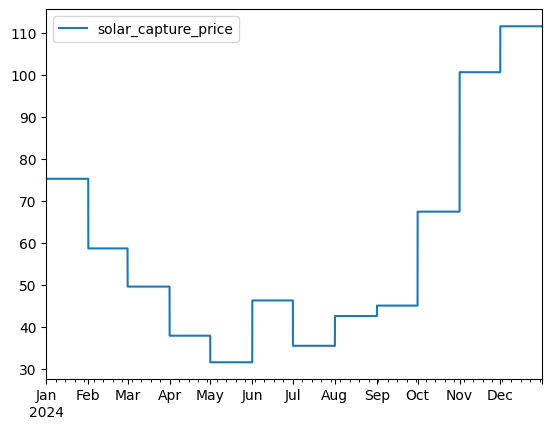

In [87]:

monthly_system_capture_prices_15min = monthly_system_capture_prices.resample('15min').ffill()
monthly_system_capture_prices_15min = monthly_system_capture_prices_15min.reindex(pd.date_range(start='2024-01-01', end='2024-12-31 23:45:00', freq='15min'), method='ffill')
monthly_system_capture_prices_15min['solar_capture_price'] = monthly_system_capture_prices_15min['solar_capture_price'].str.replace(',', '.').astype(float) * 10 # Convert to float and from EUR/kWh to EUR/MWh
monthly_system_capture_prices_15min.plot()

In [88]:
pv_output = results['pv_output']
pv_to_bess = results['p_charge_daa_ida_idc']
pv_direct_feed_in = pv_output - pv_to_bess

### Calculate two szenarios
* Szenario 1: PV direct feed in and PV to BESS sold at DAA spotmarket price
* Szenario 2: PV drect feed in sold at monthly capure price and PV to BESS sold at DAA spotmarket price

### Calculate szenarios

In [89]:
annual_pv_direct_feed_in_profit_spotmarket = (pv_direct_feed_in * daa['DAA']).sum() / 4
condition_daa_positive = results.daa_price >= 0
# annual_pv_production_excl_negative_market_price_hours = results.loc[condition_daa_positive, 'pv_output'].sum() * 15 / 60
annual_pv_direct_feed_in_profit_spotmarket_excluding_negative_daa = (pv_direct_feed_in[condition_daa_positive] * daa['DAA'][condition_daa_positive]).sum() / 4
annual_pv_to_bess_profit = (pv_to_bess * daa['DAA']).sum() / 4
annual_pv_direct_feed_in_annual_capture_price = (pv_direct_feed_in * annual_capture_price).sum() / 4
annual_pv_direct_feed_in_monthly_capture_price = (pv_direct_feed_in * monthly_system_capture_prices_15min['solar_capture_price']).sum() / 4

print("Annual PV output:", pv_output.sum() / 4) # in MWh
print("Annual PV to BESS:", pv_to_bess.sum() / 4) # in MWh
print("Annual PV direct feed-in:", pv_direct_feed_in.sum() / 4) # in MWh
print("Annual PV total (direct feed-in + to BESS):", (pv_direct_feed_in.sum() +  pv_to_bess.sum()) / 4) # in MWh
print("Annual PV direct feed-in annual capture price:", annual_pv_direct_feed_in_annual_capture_price)
print("Annual PV direct feed-in monthly capture price:", annual_pv_direct_feed_in_monthly_capture_price)
print("Annual PV direct feed-in profit spotmarket:", annual_pv_direct_feed_in_profit_spotmarket)
print("Annual PV direct feed-in profit spotmarket excl. negative price hours:", annual_pv_direct_feed_in_profit_spotmarket_excluding_negative_daa)
print("Annual PV to BESS profit:", annual_pv_to_bess_profit)
# print(f'Annual PV to BESS profit at DAA spot market price: {annual_pv_to_bess_profit:.2f} EUR')

### Calculate two szenarios
print("Szenario 1: PV direct feed in and PV to BESS sold at DAA spotmarket price:", annual_pv_direct_feed_in_profit_spotmarket_excluding_negative_daa + annual_pv_to_bess_profit)
print("Szenario 2: PV direct feed in sold at monthly capure price and PV to BESS sold at DAA spotmarket price:", annual_pv_direct_feed_in_monthly_capture_price + annual_pv_to_bess_profit)
print("Difference:", (annual_pv_direct_feed_in_monthly_capture_price - annual_pv_direct_feed_in_profit_spotmarket_excluding_negative_daa))

#### Trading fees PV
trading_fee_rate = 2.9  # €/MWh
trading_fee = pv_direct_feed_in.sum() / 4 * trading_fee_rate
print("Trading fees for PV direct feed-in:", trading_fee)

Annual PV output: 15899.987608440286
Annual PV to BESS: 4593.878246173046
Annual PV direct feed-in: 11306.10936226724
Annual PV total (direct feed-in + to BESS): 15899.987608440286
Annual PV direct feed-in annual capture price: 522794.4969112372
Annual PV direct feed-in monthly capture price: 474122.8074551792
Annual PV direct feed-in profit spotmarket: 529013.4661076906
Annual PV direct feed-in profit spotmarket excl. negative price hours: 564413.9576558089
Annual PV to BESS profit: 208592.74225614427
Szenario 1: PV direct feed in and PV to BESS sold at DAA spotmarket price: 773006.6999119532
Szenario 2: PV direct feed in sold at monthly capure price and PV to BESS sold at DAA spotmarket price: 682715.5497113235
Difference: -90291.15020062967
Trading fees for PV direct feed-in: 32787.717150574994
